In [ ]:
import time
import random
import math
import argparse
import csv
from statistics import mean, stdev
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys


In [ ]:
def exhaustive_knapsack(weights, values, capacity):
    """
    Exhaustive solver with early pruning:
    Iterate all masks from 0 to 2^n - 1; while summing bits break early if weight > capacity.
    Returns (best_value, best_mask).
    """
    n = len(weights)
    best_value = 0
    best_mask = 0
    # iterate over all subsets
    for mask in range(1 << n):
        w = 0
        v = 0
        m = mask
        i = 0
        # iterate only set bits (while m != 0)
        while m:
            if m & 1:
                w += weights[i]
                if w > capacity:
                    v = -1  # overweight -> discard
                    break
                v += values[i]
            i += 1
            m >>= 1
        if v >= 0 and v > best_value:
            best_value = v
            best_mask = mask
    return best_value, best_mask

In [ ]:
def run_instance_once(n, seed=None):
    """Generate a random instance and run the solver once. Returns a dict with info."""
    if seed is not None:
        random.seed(seed)
    weights = [random.randint(1, 100) for _ in range(n)]
    values  = [random.randint(1, 100) for _ in range(n)]
    capacity = sum(weights) // 2
    t0 = time.perf_counter()
    best_value, best_mask = exhaustive_knapsack(weights, values, capacity)
    t1 = time.perf_counter()
    elapsed = t1 - t0
    return {
        "n": n,
        "weights": weights,
        "values": values,
        "capacity": capacity,
        "time_s": elapsed,
        "best_value": best_value
    }


In [ ]:
def experiment(n_min=4, n_max=22, reps=3, base_seed=0, csv_out="knapsack_exhaustive_results.csv", max_seconds=600.0):
    """
    Runs the experiment for n in [n_min, n_max].
    Repeats each n `reps` times. Saves CSV with aggregated results.
    Stops early if mean time for some n > max_seconds.
    Returns pandas DataFrame with results.
    """
    rows = []
    for n in range(n_min, n_max + 1):
        times = []
        best_values = []
        print(f"\n=== Running n = {n} (reps={reps}) ===")
        for r in range(reps):
            seed = base_seed + n * 1000 + r
            try:
                res = run_instance_once(n, seed=seed)
            except KeyboardInterrupt:
                print("Interrupted by user. Exiting.")
                sys.exit(1)
            times.append(res["time_s"])
            best_values.append(res["best_value"])
            print(f"  rep {r+1}/{reps} -> time: {res['time_s']:.6f}s  best_value: {res['best_value']}")
        avg = mean(times)
        sd = stdev(times) if reps > 1 else 0.0
        rows.append({
            "n": n,
            "subsets": 1 << n,
            "time_mean_s": avg,
            "time_std_s": sd,
            "best_value_mean": mean(best_values)
        })
        # optional early stop
        if avg > max_seconds:
            print(f"\nMean time {avg:.2f}s for n={n} exceeds max_seconds={max_seconds}s. Stopping experiment.")
            break
    df = pd.DataFrame(rows)
    df.to_csv(csv_out, index=False)
    print(f"\nSaved results to CSV: {csv_out}")
    return df


In [ ]:
def fit_exponential_and_predict(df, target_seconds=600.0):
    """
    Fit ln(time) = a + b*n to df['n'] vs df['time_mean_s'] and predict n for target_seconds.
    Returns dict with a, b, n_pred, model function.
    """
    df2 = df[df["time_mean_s"] > 0].copy()
    if df2.empty:
        raise ValueError("No positive time measurements available for fitting.")
    x = df2["n"].values
    y = df2["time_mean_s"].values
    # Avoid log(0) issues: clamp to tiny positive
    y = np.maximum(y, 1e-12)
    lny = np.log(y)
    # Fit linear regression: lny ≈ b*n + a
    coeffs = np.polyfit(x, lny, 1)
    b = coeffs[0]
    a = coeffs[1]
    # solve for n: ln(target) = a + b*n  => n = (ln(target) - a) / b
    if abs(b) < 1e-12:
        n_pred = float("inf")
    else:
        n_pred = (math.log(target_seconds) - a) / b
    model_fn = lambda n_val: math.exp(a + b * n_val)
    return {"a": a, "b": b, "n_pred": n_pred, "model_fn": model_fn}

In [ ]:
def plot_results(df, model=None, png_out="knapsack_times.png"):
    """Plot mean times ± std and optional model curve. Y axis in log scale."""
    if df.empty:
        print("No data to plot.")
        return
    plt.figure(figsize=(8,5))
    plt.errorbar(df["n"], df["time_mean_s"], yerr=df["time_std_s"], fmt='o', capsize=3, label='measured (mean ± sd)')
    if model is not None:
        ns = np.arange(df["n"].min(), df["n"].max() + 1)
        preds = [model(nv) for nv in ns]
        plt.plot(ns, preds, linestyle='--', marker='x', label='exponential fit')
    plt.yscale('log')
    plt.xlabel('n (number of items)')
    plt.ylabel('Time (s) - log scale')
    plt.title('Exhaustive 0/1 Knapsack: time vs n')
    plt.grid(True, which="both", ls=":", linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(png_out, dpi=150)
    print(f"Saved plot to: {png_out}")
    plt.show()

In [ ]:
def main():
    parser = argparse.ArgumentParser(description="Knapsack exhaustive experiment")
    parser.add_argument("--nmin", type=int, default=4, help="Minimum n")
    parser.add_argument("--nmax", type=int, default=22, help="Maximum n to test (use caution if large)")
    parser.add_argument("--reps", type=int, default=3, help="Repetitions per n")
    parser.add_argument("--seed", type=int, default=0, help="Base random seed")
    parser.add_argument("--csv", type=str, default="knapsack_exhaustive_results.csv", help="CSV output file")
    parser.add_argument("--png", type=str, default="knapsack_times.png", help="PNG output file")
    parser.add_argument("--max-time", type=float, default=600.0, help="Stop if mean time for an n exceeds this (seconds)")
    parser.add_argument("--target-time", type=float, default=600.0, help="Target time for prediction (seconds)")
    args = parser.parse_args()

    print("Knapsack exhaustive experiment")
    print(f"Parameters: nmin={args.nmin}, nmax={args.nmax}, reps={args.reps}, seed={args.seed}")
    print("Warning: exhaustive search grows exponentially; choose nmax accordingly.")

    df = experiment(n_min=args.nmin, n_max=args.nmax, reps=args.reps,
                    base_seed=args.seed, csv_out=args.csv, max_seconds=args.max_time)

    if df.empty:
        print("No results recorded. Exiting.")
        return

    # Fit model and predict
    try:
        fit = fit_exponential_and_predict(df, target_seconds=args.target_time)
        a = fit["a"]
        b = fit["b"]
        n_pred = fit["n_pred"]
        print("\nFitted model: ln(time) = a + b * n")
        print(f"  a = {a:.6f}, b = {b:.6f}")
        if math.isfinite(n_pred):
            print(f"Estimated n for T={args.target_time}s => n_pred = {n_pred:.3f} (floor -> {int(math.floor(n_pred))})")
        else:
            print("b is too small; cannot predict n (division by near-zero).")
    except Exception as e:
        print("Could not fit model:", e)
        fit = None

    # Plot results
    model_fn = fit["model_fn"] if fit is not None else None
    plot_results(df, model=model_fn, png_out=args.png)

In [ ]:

if __name__ == "__main__":
    main()

usage: colab_kernel_launcher.py [-h] [--nmin NMIN] [--nmax NMAX] [--reps REPS]
                                [--seed SEED] [--csv CSV] [--png PNG]
                                [--max-time MAX_TIME]
                                [--target-time TARGET_TIME]
colab_kernel_launcher.py: error: unrecognized arguments: -f /root/.local/share/jupyter/runtime/kernel-51277dc1-76b0-4b81-ab31-aabd627b20b7.json


SystemExit: 2

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
#!/usr/bin/env python3
# knapsack_exhaustive_experiment.py
# Complete reproducible experiment: exhaustive 0/1 knapsack, timing, CSV and PNG output.
# Usage example:
#   python knapsack_exhaustive_experiment.py --nmin 4 --nmax 22 --reps 3 --seed 0
#
# Requirements:
#   pip install pandas numpy matplotlib

import time
import random
import math
import argparse
import csv
from statistics import mean, stdev
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

def exhaustive_knapsack(weights, values, capacity):
    """
    Exhaustive solver with early pruning:
    Iterate all masks from 0 to 2^n - 1; while summing bits break early if weight > capacity.
    Returns (best_value, best_mask).
    """
    n = len(weights)
    best_value = 0
    best_mask = 0
    # iterate over all subsets
    for mask in range(1 << n):
        w = 0
        v = 0
        m = mask
        i = 0
        # iterate only set bits (while m != 0)
        while m:
            if m & 1:
                w += weights[i]
                if w > capacity:
                    v = -1  # overweight -> discard
                    break
                v += values[i]
            i += 1
            m >>= 1
        if v >= 0 and v > best_value:
            best_value = v
            best_mask = mask
    return best_value, best_mask

def run_instance_once(n, seed=None):
    """Generate a random instance and run the solver once. Returns a dict with info."""
    if seed is not None:
        random.seed(seed)
    weights = [random.randint(1, 100) for _ in range(n)]
    values  = [random.randint(1, 100) for _ in range(n)]
    capacity = sum(weights) // 2
    t0 = time.perf_counter()
    best_value, best_mask = exhaustive_knapsack(weights, values, capacity)
    t1 = time.perf_counter()
    elapsed = t1 - t0
    return {
        "n": n,
        "weights": weights,
        "values": values,
        "capacity": capacity,
        "time_s": elapsed,
        "best_value": best_value
    }

def experiment(n_min=4, n_max=22, reps=3, base_seed=0, csv_out="knapsack_exhaustive_results.csv", max_seconds=600.0):
    """
    Runs the experiment for n in [n_min, n_max].
    Repeats each n `reps` times. Saves CSV with aggregated results.
    Stops early if mean time for some n > max_seconds.
    Returns pandas DataFrame with results.
    """
    rows = []
    for n in range(n_min, n_max + 1):
        times = []
        best_values = []
        print(f"\n=== Running n = {n} (reps={reps}) ===")
        for r in range(reps):
            seed = base_seed + n * 1000 + r
            try:
                res = run_instance_once(n, seed=seed)
            except KeyboardInterrupt:
                print("Interrupted by user. Exiting.")
                sys.exit(1)
            times.append(res["time_s"])
            best_values.append(res["best_value"])
            print(f"  rep {r+1}/{reps} -> time: {res['time_s']:.6f}s  best_value: {res['best_value']}")
        avg = mean(times)
        sd = stdev(times) if reps > 1 else 0.0
        rows.append({
            "n": n,
            "subsets": 1 << n,
            "time_mean_s": avg,
            "time_std_s": sd,
            "best_value_mean": mean(best_values)
        })
        # optional early stop
        if avg > max_seconds:
            print(f"\nMean time {avg:.2f}s for n={n} exceeds max_seconds={max_seconds}s. Stopping experiment.")
            break
    df = pd.DataFrame(rows)
    df.to_csv(csv_out, index=False)
    print(f"\nSaved results to CSV: {csv_out}")
    return df

def fit_exponential_and_predict(df, target_seconds=600.0):
    """
    Fit ln(time) = a + b*n to df['n'] vs df['time_mean_s'] and predict n for target_seconds.
    Returns dict with a, b, n_pred, model function.
    """
    df2 = df[df["time_mean_s"] > 0].copy()
    if df2.empty:
        raise ValueError("No positive time measurements available for fitting.")
    x = df2["n"].values
    y = df2["time_mean_s"].values
    # Avoid log(0) issues: clamp to tiny positive
    y = np.maximum(y, 1e-12)
    lny = np.log(y)
    # Fit linear regression: lny ≈ b*n + a
    coeffs = np.polyfit(x, lny, 1)
    b = coeffs[0]
    a = coeffs[1]
    # solve for n: ln(target) = a + b*n  => n = (ln(target) - a) / b
    if abs(b) < 1e-12:
        n_pred = float("inf")
    else:
        n_pred = (math.log(target_seconds) - a) / b
    model_fn = lambda n_val: math.exp(a + b * n_val)
    return {"a": a, "b": b, "n_pred": n_pred, "model_fn": model_fn}

def plot_results(df, model=None, png_out="knapsack_times.png"):
    """Plot mean times ± std and optional model curve. Y axis in log scale."""
    if df.empty:
        print("No data to plot.")
        return
    plt.figure(figsize=(8,5))
    plt.errorbar(df["n"], df["time_mean_s"], yerr=df["time_std_s"], fmt='o', capsize=3, label='measured (mean ± sd)')
    if model is not None:
        ns = np.arange(df["n"].min(), df["n"].max() + 1)
        preds = [model(nv) for nv in ns]
        plt.plot(ns, preds, linestyle='--', marker='x', label='exponential fit')
    plt.yscale('log')
    plt.xlabel('n (number of items)')
    plt.ylabel('Time (s) - log scale')
    plt.title('Exhaustive 0/1 Knapsack: time vs n')
    plt.grid(True, which="both", ls=":", linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(png_out, dpi=150)
    print(f"Saved plot to: {png_out}")
    plt.show()

def main():
    parser = argparse.ArgumentParser(description="Knapsack exhaustive experiment")
    parser.add_argument("--nmin", type=int, default=4, help="Minimum n")
    parser.add_argument("--nmax", type=int, default=22, help="Maximum n to test (use caution if large)")
    parser.add_argument("--reps", type=int, default=3, help="Repetitions per n")
    parser.add_argument("--seed", type=int, default=0, help="Base random seed")
    parser.add_argument("--csv", type=str, default="knapsack_exhaustive_results.csv", help="CSV output file")
    parser.add_argument("--png", type=str, default="knapsack_times.png", help="PNG output file")
    parser.add_argument("--max-time", type=float, default=600.0, help="Stop if mean time for an n exceeds this (seconds)")
    parser.add_argument("--target-time", type=float, default=600.0, help="Target time for prediction (seconds)")
    args = parser.parse_args()

    print("Knapsack exhaustive experiment")
    print(f"Parameters: nmin={args.nmin}, nmax={args.nmax}, reps={args.reps}, seed={args.seed}")
    print("Warning: exhaustive search grows exponentially; choose nmax accordingly.")

    df = experiment(n_min=args.nmin, n_max=args.nmax, reps=args.reps,
                    base_seed=args.seed, csv_out=args.csv, max_seconds=args.max_time)

    if df.empty:
        print("No results recorded. Exiting.")
        return

    # Fit model and predict
    try:
        fit = fit_exponential_and_predict(df, target_seconds=args.target_time)
        a = fit["a"]
        b = fit["b"]
        n_pred = fit["n_pred"]
        print("\nFitted model: ln(time) = a + b * n")
        print(f"  a = {a:.6f}, b = {b:.6f}")
        if math.isfinite(n_pred):
            print(f"Estimated n for T={args.target_time}s => n_pred = {n_pred:.3f} (floor -> {int(math.floor(n_pred))})")
        else:
            print("b is too small; cannot predict n (division by near-zero).")
    except Exception as e:
        print("Could not fit model:", e)
        fit = None

    # Plot results
    model_fn = fit["model_fn"] if fit is not None else None
    plot_results(df, model=model_fn, png_out=args.png)

if __name__ == "__main__":
    main()

usage: colab_kernel_launcher.py [-h] [--nmin NMIN] [--nmax NMAX] [--reps REPS]
                                [--seed SEED] [--csv CSV] [--png PNG]
                                [--max-time MAX_TIME]
                                [--target-time TARGET_TIME]
colab_kernel_launcher.py: error: unrecognized arguments: -f /root/.local/share/jupyter/runtime/kernel-51277dc1-76b0-4b81-ab31-aabd627b20b7.json


SystemExit: 2

Knapsack exhaustive experiment
Parameters: nmin=4, nmax=22, reps=3, seed=0

=== Running n = 4 (reps=3) ===
  rep 1/3 -> time: 0.000017s  best_value: 158
  rep 2/3 -> time: 0.000012s  best_value: 163
  rep 3/3 -> time: 0.000011s  best_value: 128

=== Running n = 5 (reps=3) ===
  rep 1/3 -> time: 0.000024s  best_value: 161
  rep 2/3 -> time: 0.000026s  best_value: 189
  rep 3/3 -> time: 0.000020s  best_value: 199

=== Running n = 6 (reps=3) ===
  rep 1/3 -> time: 0.000055s  best_value: 219
  rep 2/3 -> time: 0.000056s  best_value: 309
  rep 3/3 -> time: 0.000062s  best_value: 219

=== Running n = 7 (reps=3) ===
  rep 1/3 -> time: 0.000135s  best_value: 206
  rep 2/3 -> time: 0.000140s  best_value: 226
  rep 3/3 -> time: 0.000140s  best_value: 112

=== Running n = 8 (reps=3) ===
  rep 1/3 -> time: 0.000321s  best_value: 275
  rep 2/3 -> time: 0.000316s  best_value: 344
  rep 3/3 -> time: 0.000324s  best_value: 285

=== Running n = 9 (reps=3) ===
  rep 1/3 -> time: 0.000815s  best_value: 2

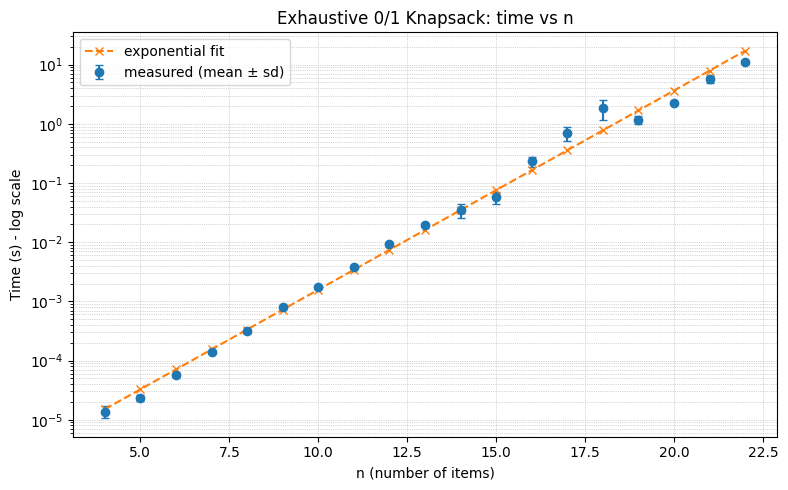

In [1]:
#!/usr/bin/env python3
# knapsack_exhaustive_experiment.py
# Fixed: use parse_known_args() so the script tolerates Jupyter/Colab kernel args.

import time
import random
import math
import argparse
import sys
from statistics import mean, stdev
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def exhaustive_knapsack(weights, values, capacity):
    n = len(weights)
    best_value = 0
    best_mask = 0
    for mask in range(1 << n):
        w = 0
        v = 0
        m = mask
        i = 0
        while m:
            if m & 1:
                w += weights[i]
                if w > capacity:
                    v = -1
                    break
                v += values[i]
            i += 1
            m >>= 1
        if v >= 0 and v > best_value:
            best_value = v
            best_mask = mask
    return best_value, best_mask

def run_instance_once(n, seed=None):
    if seed is not None:
        random.seed(seed)
    weights = [random.randint(1, 100) for _ in range(n)]
    values  = [random.randint(1, 100) for _ in range(n)]
    capacity = sum(weights) // 2
    t0 = time.perf_counter()
    best_value, best_mask = exhaustive_knapsack(weights, values, capacity)
    t1 = time.perf_counter()
    return {
        "n": n,
        "weights": weights,
        "values": values,
        "capacity": capacity,
        "time_s": t1 - t0,
        "best_value": best_value
    }

def experiment(n_min=4, n_max=22, reps=3, base_seed=0, csv_out="knapsack_exhaustive_results.csv", max_seconds=600.0):
    rows = []
    for n in range(n_min, n_max + 1):
        times = []
        best_values = []
        print(f"\n=== Running n = {n} (reps={reps}) ===")
        for r in range(reps):
            seed = base_seed + n * 1000 + r
            res = run_instance_once(n, seed=seed)
            times.append(res["time_s"])
            best_values.append(res["best_value"])
            print(f"  rep {r+1}/{reps} -> time: {res['time_s']:.6f}s  best_value: {res['best_value']}")
        avg = mean(times)
        sd = stdev(times) if reps > 1 else 0.0
        rows.append({
            "n": n,
            "subsets": 1 << n,
            "time_mean_s": avg,
            "time_std_s": sd,
            "best_value_mean": mean(best_values)
        })
        if avg > max_seconds:
            print(f"\nMean time {avg:.2f}s for n={n} exceeds max_seconds={max_seconds}s. Stopping experiment.")
            break
    df = pd.DataFrame(rows)
    df.to_csv(csv_out, index=False)
    print(f"\nSaved results to CSV: {csv_out}")
    return df

def fit_exponential_and_predict(df, target_seconds=600.0):
    df2 = df[df["time_mean_s"] > 0].copy()
    if df2.empty:
        raise ValueError("No positive time measurements available for fitting.")
    x = df2["n"].values
    y = df2["time_mean_s"].values
    y = np.maximum(y, 1e-12)
    lny = np.log(y)
    coeffs = np.polyfit(x, lny, 1)
    b = coeffs[0]
    a = coeffs[1]
    if abs(b) < 1e-12:
        n_pred = float("inf")
    else:
        n_pred = (math.log(target_seconds) - a) / b
    model_fn = lambda n_val: math.exp(a + b * n_val)
    return {"a": a, "b": b, "n_pred": n_pred, "model_fn": model_fn}

def plot_results(df, model=None, png_out="knapsack_times.png"):
    if df.empty:
        print("No data to plot.")
        return
    plt.figure(figsize=(8,5))
    plt.errorbar(df["n"], df["time_mean_s"], yerr=df["time_std_s"], fmt='o', capsize=3, label='measured (mean ± sd)')
    if model is not None:
        ns = np.arange(df["n"].min(), df["n"].max() + 1)
        preds = [model(nv) for nv in ns]
        plt.plot(ns, preds, linestyle='--', marker='x', label='exponential fit')
    plt.yscale('log')
    plt.xlabel('n (number of items)')
    plt.ylabel('Time (s) - log scale')
    plt.title('Exhaustive 0/1 Knapsack: time vs n')
    plt.grid(True, which="both", ls=":", linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(png_out, dpi=150)
    print(f"Saved plot to: {png_out}")
    plt.show()

def main(argv=None):
    parser = argparse.ArgumentParser(description="Knapsack exhaustive experiment")
    parser.add_argument("--nmin", type=int, default=4, help="Minimum n")
    parser.add_argument("--nmax", type=int, default=22, help="Maximum n to test")
    parser.add_argument("--reps", type=int, default=3, help="Repetitions per n")
    parser.add_argument("--seed", type=int, default=0, help="Base random seed")
    parser.add_argument("--csv", type=str, default="knapsack_exhaustive_results.csv", help="CSV output file")
    parser.add_argument("--png", type=str, default="knapsack_times.png", help="PNG output file")
    parser.add_argument("--max-time", type=float, default=600.0, help="Stop if mean time for an n exceeds this (seconds)")
    parser.add_argument("--target-time", type=float, default=600.0, help="Target time for prediction (seconds)")

    # Use parse_known_args so kernel-injected args (e.g. -f /path/kernel-...) are ignored.
    if argv is None:
        args, unknown = parser.parse_known_args()
    else:
        args = parser.parse_args(argv)

    print("Knapsack exhaustive experiment")
    print(f"Parameters: nmin={args.nmin}, nmax={args.nmax}, reps={args.reps}, seed={args.seed}")
    print("Warning: exhaustive search grows exponentially; choose nmax accordingly.")

    df = experiment(n_min=args.nmin, n_max=args.nmax, reps=args.reps,
                    base_seed=args.seed, csv_out=args.csv, max_seconds=args.max_time)

    if df.empty:
        print("No results recorded. Exiting.")
        return

    try:
        fit = fit_exponential_and_predict(df, target_seconds=args.target_time)
        a = fit["a"]
        b = fit["b"]
        n_pred = fit["n_pred"]
        print("\nFitted model: ln(time) = a + b * n")
        print(f"  a = {a:.6f}, b = {b:.6f}")
        if math.isfinite(n_pred):
            print(f"Estimated n for T={args.target_time}s => n_pred = {n_pred:.3f} (floor -> {int(math.floor(n_pred))})")
        else:
            print("b is too small; cannot predict n (division by near-zero).")
    except Exception as e:
        print("Could not fit model:", e)
        fit = None

    model_fn = fit["model_fn"] if fit is not None else None
    plot_results(df, model=model_fn, png_out=args.png)

if __name__ == "__main__":
    # pass None so main uses parse_known_args() on sys.argv (robust in notebooks)
    main()

In [2]:
# dfs_graph_py.py
from collections import defaultdict, deque

class Graph:
    def __init__(self, n):
        self.n = n
        self.adj = defaultdict(list)
        self.value = [0]*n

    def add_edge(self,u,v):
        self.adj[u].append(v)
        self.adj[v].append(u)   # undirected

def dfs_recursive(g, u, visited):
    visited[u] = True
    print(f"Visited node {u}: value = {g.value[u]}")
    for v in g.adj[u]:
        if not visited[v]:
            dfs_recursive(g, v, visited)

def dfs_iter(g, start):
    visited = [False]*g.n
    stack = [start]
    while stack:
        u = stack.pop()
        if visited[u]: continue
        visited[u]=True
        print(f"Visited node {u}: value = {g.value[u]}")
        for v in g.adj[u]:
            if not visited[v]:
                stack.append(v)

# example
g = Graph(7)
for i in range(7): g.value[i] = i*10+5
edges = [(0,1),(0,2),(1,3),(1,4),(2,5),(5,6)]
for u,v in edges: g.add_edge(u,v)
print("Recursive")
dfs_recursive(g, 0, [False]*7)
print("Iterative")
dfs_iter(g, 0)

Recursive
Visited node 0: value = 5
Visited node 1: value = 15
Visited node 3: value = 35
Visited node 4: value = 45
Visited node 2: value = 25
Visited node 5: value = 55
Visited node 6: value = 65
Iterative
Visited node 0: value = 5
Visited node 2: value = 25
Visited node 5: value = 55
Visited node 6: value = 65
Visited node 1: value = 15
Visited node 4: value = 45
Visited node 3: value = 35


In [3]:
pip install networkx matplotlib

Saved figure to dfs_traversal_comparison.png


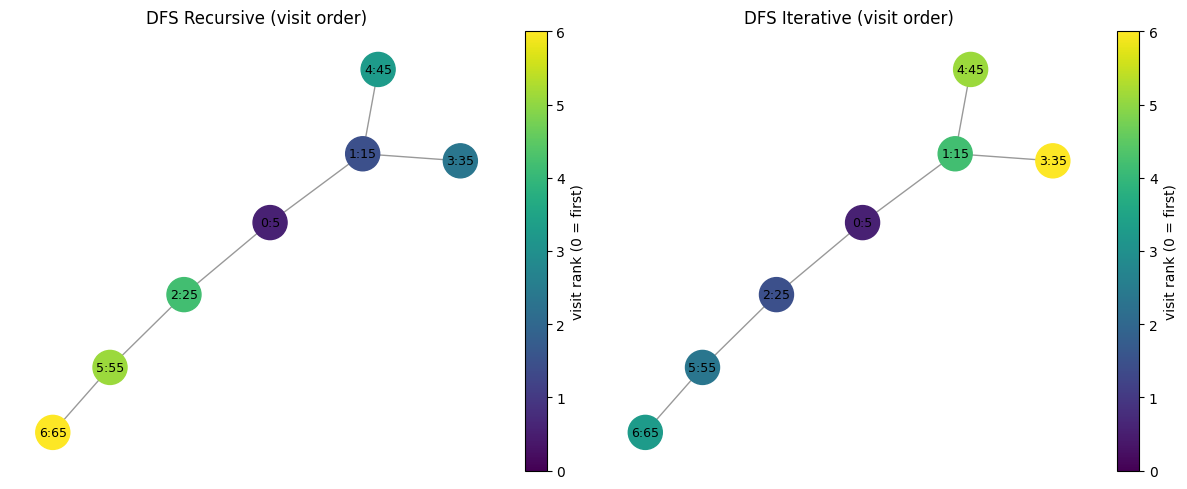


Recursive order (node:id:value):
 0: node 0 value=5
 1: node 1 value=15
 2: node 3 value=35
 3: node 4 value=45
 4: node 2 value=25
 5: node 5 value=55
 6: node 6 value=65

Iterative order (node:id:value):
 0: node 0 value=5
 1: node 2 value=25
 2: node 5 value=55
 3: node 6 value=65
 4: node 1 value=15
 5: node 4 value=45
 6: node 3 value=35


In [4]:
# visualization_block.py
# Añade esto al final de tu script (o como script nuevo).
import matplotlib.pyplot as plt
import networkx as nx

# --- versiones de DFS que registran orden ---
def dfs_recursive_record(g, u, visited, order):
    visited[u] = True
    order.append(u)
    for v in g.adj[u]:
        if not visited[v]:
            dfs_recursive_record(g, v, visited, order)

def dfs_iter_record(g, start):
    visited = [False]*g.n
    stack = [start]
    order = []
    while stack:
        u = stack.pop()
        if visited[u]:
            continue
        visited[u] = True
        order.append(u)
        # si quieres imitar exactamente el orden recursivo,
        # usa reversed(g.adj[u]) al apilar
        for v in g.adj[u]:
            if not visited[v]:
                stack.append(v)
    return order

# --- construir el grafo con networkx ---
def build_nx_graph(g):
    G = nx.Graph()
    G.add_nodes_from(range(g.n))
    # añadir aristas (en g ya están añadidas)
    added = set()
    for u in g.adj:
        for v in g.adj[u]:
            if (u,v) not in added and (v,u) not in added:
                G.add_edge(u, v)
                added.add((u,v))
    return G

# --- preparar datos y ejecutar DFS contabilizando orden ---
# Reuse el grafo 'g' creado antes en tu script
rec_order = []
visited = [False]*g.n
dfs_recursive_record(g, 0, visited, rec_order)

iter_order = dfs_iter_record(g, 0)

# --- mapa nodo -> posición en la visita (0-based) ---
rec_pos = {node: i for i, node in enumerate(rec_order)}
iter_pos = {node: i for i, node in enumerate(iter_order)}

# --- dibujar: dos subplots lado a lado ---
Gnx = build_nx_graph(g)
pos = nx.spring_layout(Gnx, seed=42)  # layout estable

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# función auxiliar para preparar colores/labels
def draw_with_order(ax, order_map, title):
    # Colores basados en orden de visita; los no visitados toman valor -1
    max_order = max(order_map.values()) if order_map else 0
    node_color = []
    for node in Gnx.nodes():
        if node in order_map:
            # escala 0..1
            node_color.append(order_map[node] / max(1, max_order))
        else:
            node_color.append(-0.1)  # nodos no visitados (si los hay)
    # Nodo label: "id:value"
    labels = {n: f"{n}:{g.value[n]}" for n in Gnx.nodes()}
    # dibujar nodos (colormap)
    nx.draw_networkx_edges(Gnx, pos=pos, ax=ax, alpha=0.4)
    nodes = nx.draw_networkx_nodes(
        Gnx, pos=pos, ax=ax,
        node_size=600,
        node_color=node_color,
        cmap=plt.cm.viridis,
        vmin=-0.1, vmax=1.0
    )
    nx.draw_networkx_labels(Gnx, pos=pos, labels=labels, ax=ax, font_size=9)
    ax.set_title(title)
    ax.axis('off')
    # agregar colorbar que muestre "visit order" si hay visitantes
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=max(1, max_order)))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('visit rank (0 = first)')

# dibujar recursiva
draw_with_order(axes[0], rec_pos, "DFS Recursive (visit order)")

# dibujar iterativa
draw_with_order(axes[1], iter_pos, "DFS Iterative (visit order)")

plt.tight_layout()
plt.savefig("dfs_traversal_comparison.png", dpi=150)
print("Saved figure to dfs_traversal_comparison.png")
plt.show()

# --- además, imprime los órdenes (útil para el informe) ---
print("\nRecursive order (node:id:value):")
for i, node in enumerate(rec_order):
    print(f"{i:2d}: node {node} value={g.value[node]}")

print("\nIterative order (node:id:value):")
for i, node in enumerate(iter_order):
    print(f"{i:2d}: node {node} value={g.value[node]}")

In [5]:
# bfs_graph_py.py
from collections import defaultdict, deque

class Graph:
    def __init__(self, n):
        self.n = n
        self.adj = defaultdict(list)
        self.value = [0] * n

    def add_edge(self, u, v):
        # undirected edge
        self.adj[u].append(v)
        self.adj[v].append(u)

    def sort_adj(self):
        # optional: makes traversal order deterministic
        for u in range(self.n):
            self.adj[u].sort()

def bfs_from(g: Graph, start: int, print_values: bool = True):
    """
    BFS starting at `start`. Marks visited and prints each node's value
    when the node is dequeued (first discovered).
    Returns the visit order (list of node indices).
    """
    visited = [False] * g.n
    q = deque()
    order = []

    visited[start] = True
    q.append(start)

    while q:
        u = q.popleft()
        order.append(u)
        if print_values:
            print(f"Visited node {u}: value = {g.value[u]}")
        for v in g.adj[u]:
            if not visited[v]:
                visited[v] = True
                q.append(v)
    return order

def bfs_full(g: Graph, print_values: bool = True):
    """
    Run BFS on every component: for all vertices u, if not yet visited,
    start a BFS from u. Prints values for the whole graph and returns
    a list of visit orders per component.
    """
    visited = [False] * g.n
    components_orders = []

    for s in range(g.n):
        if not visited[s]:
            q = deque([s])
            visited[s] = True
            comp_order = []
            while q:
                u = q.popleft()
                comp_order.append(u)
                if print_values:
                    print(f"Visited node {u}: value = {g.value[u]}")
                for v in g.adj[u]:
                    if not visited[v]:
                        visited[v] = True
                        q.append(v)
            components_orders.append(comp_order)

    return components_orders

# -------------------------
# Example usage (same test graph you used earlier)
# -------------------------
if __name__ == "__main__":
    g = Graph(7)
    for i in range(7):
        g.value[i] = i * 10 + 5
    edges = [(0,1),(0,2),(1,3),(1,4),(2,5),(5,6)]
    for u, v in edges:
        g.add_edge(u, v)

    # Optional: sort adjacency lists to make traversal order deterministic
    # g.sort_adj()

    print("BFS from node 0:")
    bfs_order = bfs_from(g, 0)   # prints values while running

    print("\nFull BFS (all components):")
    # If graph is connected these lists will contain a single component order
    comps = bfs_full(g)
    # comps is a list of lists; example: [[0,1,2,3,4,5,6]]

BFS from node 0:
Visited node 0: value = 5
Visited node 1: value = 15
Visited node 2: value = 25
Visited node 3: value = 35
Visited node 4: value = 45
Visited node 5: value = 55
Visited node 6: value = 65

Full BFS (all components):
Visited node 0: value = 5
Visited node 1: value = 15
Visited node 2: value = 25
Visited node 3: value = 35
Visited node 4: value = 45
Visited node 5: value = 55
Visited node 6: value = 65


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

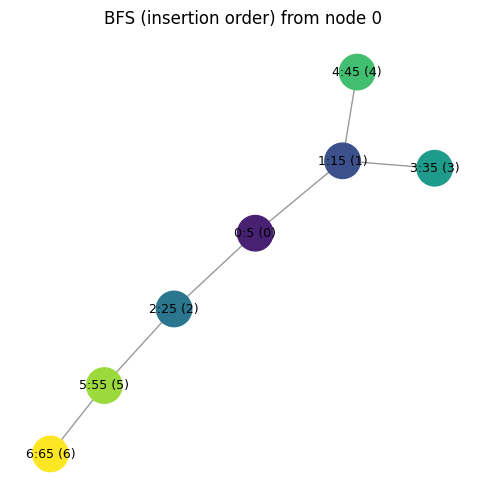

In [6]:
# paste after your BFS code (or in a new script)
import networkx as nx
import matplotlib.pyplot as plt
from copy import deepcopy

# helper to build a networkx graph from Graph g (avoid duplicate edges)
def build_nx_graph_from_graph(g):
    G = nx.Graph()
    G.add_nodes_from(range(g.n))
    seen = set()
    for u in range(g.n):
        for v in g.adj[u]:
            if (u, v) in seen or (v, u) in seen:
                continue
            G.add_edge(u, v)
            seen.add((u, v))
    return G

# draw and save a single BFS-visit-order figure
def draw_bfs_order(g, order, filename, title="BFS visit order"):
    Gnx = build_nx_graph_from_graph(g)
    pos = nx.spring_layout(Gnx, seed=42)  # stable layout
    order_map = {node: i for i, node in enumerate(order)}
    max_order = max(order_map.values()) if order_map else 0

    # node colors: map visit index -> 0..1
    node_colors = []
    for n in Gnx.nodes():
        if n in order_map:
            node_colors.append(order_map[n] / max(1, max_order))
        else:
            node_colors.append(-0.1)

    # labels show id:value (rank)
    labels = {}
    for n in Gnx.nodes():
        val = g.value[n]
        if n in order_map:
            labels[n] = f"{n}:{val} ({order_map[n]})"
        else:
            labels[n] = f"{n}:{val} (-)"

    plt.figure(figsize=(6,6))
    nx.draw_networkx_edges(Gnx, pos=pos, alpha=0.4)
    nodes = nx.draw_networkx_nodes(
        Gnx, pos=pos,
        node_size=650,
        node_color=node_colors,
        cmap=plt.cm.viridis,
        vmin=-0.1, vmax=1.0
    )
    nx.draw_networkx_labels(Gnx, pos=pos, labels=labels, font_size=9)
    plt.title(title)
    plt.axis('off')
    # colorbar for visit rank (0 = first)
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=max(1, max_order)))
    sm.set_array([])
    cbar = plt.colorbar(sm, fraction=0.046, pad=0.04)
    cbar.set_label('visit rank (0 = first)')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.close()
    print(f"Saved {filename}")

# --- Build two graph variants and get BFS orders ---
# Option A: use the graph as-built (insertion order)
g_original = deepcopy(g)   # assumes g exists from your earlier code
order_orig = bfs_from(g_original, 0, print_values=False)

# Option B: deterministic order: rebuild graph and sort adjacency lists
# We'll rebuild from the original edges to ensure same structure.
# If you have `edges` list in scope (as in your example), use it; otherwise, extract edges.
try:
    edges_list = edges  # from your script
except NameError:
    # extract edges from g (avoid duplicates)
    edges_list = []
    seen = set()
    for u in range(g.n):
        for v in g.adj[u]:
            if (u,v) in seen or (v,u) in seen:
                continue
            edges_list.append((u,v))
            seen.add((u,v))

g_sorted = Graph(g.n)
g_sorted.value = g.value[:]  # copy values
for (u,v) in edges_list:
    g_sorted.add_edge(u, v)
g_sorted.sort_adj()  # sort adjacency lists to force deterministic BFS order
order_sorted = bfs_from(g_sorted, 0, print_values=False)

# --- Draw two separate figures (one file each) ---
draw_bfs_order(g_original, order_orig, "bfs_original.png", title="BFS (insertion order) from node 0")
draw_bfs_order(g_sorted, order_sorted, "bfs_sorted.png", title="BFS (sorted adjacency) from node 0")

# Print the orders (useful for the report)
print("BFS order (original):", order_orig)
print("BFS order (sorted):  ", order_sorted)

In [8]:
# corrected draw_bfs_order + usage
import networkx as nx
import matplotlib.pyplot as plt

def build_nx_graph_from_graph(g):
    G = nx.Graph()
    G.add_nodes_from(range(g.n))
    seen = set()
    for u in range(g.n):
        for v in g.adj[u]:
            if (u, v) in seen or (v, u) in seen:
                continue
            G.add_edge(u, v)
            seen.add((u, v))
    return G

def draw_bfs_order(g, order, filename, title="BFS visit order"):
    Gnx = build_nx_graph_from_graph(g)
    pos = nx.spring_layout(Gnx, seed=42)

    order_map = {node: i for i, node in enumerate(order)}
    max_order = max(order_map.values()) if order_map else 0

    # compute node_colors normalized to 0..1 (nodes not visited get -0.1)
    node_colors = []
    for n in Gnx.nodes():
        if n in order_map:
            node_colors.append(order_map[n] / max(1, max_order))
        else:
            node_colors.append(-0.1)

    # build labels "id:value (rank)"
    labels = {}
    for n in Gnx.nodes():
        val = g.value[n]
        if n in order_map:
            labels[n] = f"{n}:{val} ({order_map[n]})"
        else:
            labels[n] = f"{n}:{val} (-)"

    # create figure and axis explicitly (important!)
    fig, ax = plt.subplots(figsize=(6,6))

    # draw graph on ax
    nx.draw_networkx_edges(Gnx, pos=pos, ax=ax, alpha=0.4)
    nodes = nx.draw_networkx_nodes(
        Gnx, pos=pos, ax=ax,
        node_size=650,
        node_color=node_colors,
        cmap=plt.cm.viridis,
        vmin=-0.1, vmax=1.0
    )
    nx.draw_networkx_labels(Gnx, pos=pos, labels=labels, ax=ax, font_size=9)

    ax.set_title(title)
    ax.axis('off')

    # create a ScalarMappable for the colorbar, and attach it to fig via ax
    # handle degenerate case (max_order == 0) by normalizing with max(1,max_order)
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,
                               norm=plt.Normalize(vmin=0, vmax=max(1, max_order)))
    sm.set_array([])  # required for colorbar
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('visit rank (0 = first)')

    plt.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.close(fig)
    print(f"Saved {filename}")

# --- Example usage (after building your Graph g and computing BFS orders) ---
# order_orig = bfs_from(g_original, 0, print_values=False)
# order_sorted = bfs_from(g_sorted, 0, print_values=False)
# draw_bfs_order(g_original, order_orig, "bfs_original.png", title="BFS (insertion order) from node 0")
# draw_bfs_order(g_sorted, order_sorted, "bfs_sorted.png", title="BFS (sorted adjacency) from node 0")

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

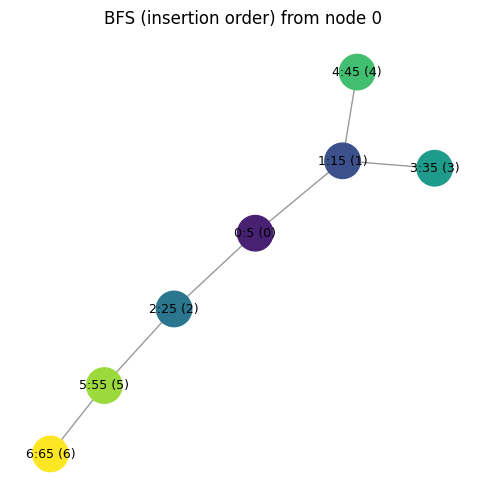

In [9]:
# paste after your BFS code (or in a new script)
import networkx as nx
import matplotlib.pyplot as plt
from copy import deepcopy

# helper to build a networkx graph from Graph g (avoid duplicate edges)
def build_nx_graph_from_graph(g):
    G = nx.Graph()
    G.add_nodes_from(range(g.n))
    seen = set()
    for u in range(g.n):
        for v in g.adj[u]:
            if (u, v) in seen or (v, u) in seen:
                continue
            G.add_edge(u, v)
            seen.add((u, v))
    return G

# draw and save a single BFS-visit-order figure
def draw_bfs_order(g, order, filename, title="BFS visit order"):
    Gnx = build_nx_graph_from_graph(g)
    pos = nx.spring_layout(Gnx, seed=42)  # stable layout
    order_map = {node: i for i, node in enumerate(order)}
    max_order = max(order_map.values()) if order_map else 0

    # node colors: map visit index -> 0..1
    node_colors = []
    for n in Gnx.nodes():
        if n in order_map:
            node_colors.append(order_map[n] / max(1, max_order))
        else:
            node_colors.append(-0.1)

    # labels show id:value (rank)
    labels = {}
    for n in Gnx.nodes():
        val = g.value[n]
        if n in order_map:
            labels[n] = f"{n}:{val} ({order_map[n]})"
        else:
            labels[n] = f"{n}:{val} (-)"

    plt.figure(figsize=(6,6))
    nx.draw_networkx_edges(Gnx, pos=pos, alpha=0.4)
    nodes = nx.draw_networkx_nodes(
        Gnx, pos=pos,
        node_size=650,
        node_color=node_colors,
        cmap=plt.cm.viridis,
        vmin=-0.1, vmax=1.0
    )
    nx.draw_networkx_labels(Gnx, pos=pos, labels=labels, font_size=9)
    plt.title(title)
    plt.axis('off')
    # colorbar for visit rank (0 = first)
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=max(1, max_order)))
    sm.set_array([])
    cbar = plt.colorbar(sm, fraction=0.046, pad=0.04)
    cbar.set_label('visit rank (0 = first)')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.close()
    print(f"Saved {filename}")

# --- Build two graph variants and get BFS orders ---
# Option A: use the graph as-built (insertion order)
g_original = deepcopy(g)   # assumes g exists from your earlier code
order_orig = bfs_from(g_original, 0, print_values=False)

# Option B: deterministic order: rebuild graph and sort adjacency lists
# We'll rebuild from the original edges to ensure same structure.
# If you have `edges` list in scope (as in your example), use it; otherwise, extract edges.
try:
    edges_list = edges  # from your script
except NameError:
    # extract edges from g (avoid duplicates)
    edges_list = []
    seen = set()
    for u in range(g.n):
        for v in g.adj[u]:
            if (u,v) in seen or (v,u) in seen:
                continue
            edges_list.append((u,v))
            seen.add((u,v))

g_sorted = Graph(g.n)
g_sorted.value = g.value[:]  # copy values
for (u,v) in edges_list:
    g_sorted.add_edge(u, v)
g_sorted.sort_adj()  # sort adjacency lists to force deterministic BFS order
order_sorted = bfs_from(g_sorted, 0, print_values=False)

# --- Draw two separate figures (one file each) ---
draw_bfs_order(g_original, order_orig, "bfs_original.png", title="BFS (insertion order) from node 0")
draw_bfs_order(g_sorted, order_sorted, "bfs_sorted.png", title="BFS (sorted adjacency) from node 0")

# Print the orders (useful for the report)
print("BFS order (original):", order_orig)
print("BFS order (sorted):  ", order_sorted)

In [10]:
# bfs_plot_generate.py
# Save and run: python bfs_plot_generate.py
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, deque
from copy import deepcopy
import os

class Graph:
    def __init__(self, n):
        self.n = n
        self.adj = defaultdict(list)
        self.value = [0] * n
    def add_edge(self, u, v):
        self.adj[u].append(v)
        self.adj[v].append(u)
    def sort_adj(self):
        for u in range(self.n):
            self.adj[u].sort()

def bfs_from(g: Graph, start: int, print_values: bool = False):
    visited = [False] * g.n
    q = deque()
    order = []
    visited[start] = True
    q.append(start)
    while q:
        u = q.popleft()
        order.append(u)
        if print_values:
            print(f"Visited node {u}: value = {g.value[u]}")
        for v in g.adj[u]:
            if not visited[v]:
                visited[v] = True
                q.append(v)
    return order

def build_nx_graph_from_graph(g):
    G = nx.Graph()
    G.add_nodes_from(range(g.n))
    seen = set()
    for u in range(g.n):
        for v in g.adj[u]:
            if (u, v) in seen or (v, u) in seen:
                continue
            G.add_edge(u, v)
            seen.add((u, v))
    return G

def draw_bfs_order(g, order, filename, title="BFS visit order"):
    """
    Draws the graph and labels each node as "id:value (rank)" where rank is
    the 0-based visit index. Saves the figure to filename (PNG).
    This function avoids using explicit color maps (safer for embedding and
    avoids previous colorbar issue).
    """
    Gnx = build_nx_graph_from_graph(g)
    pos = nx.spring_layout(Gnx, seed=42)  # stable layout
    order_map = {node: i for i, node in enumerate(order)}
    labels = {n: (f"{n}:{g.value[n]} ({order_map[n]})" if n in order_map else f"{n}:{g.value[n]} (-)") for n in Gnx.nodes()}

    fig, ax = plt.subplots(figsize=(6,6))
    nx.draw_networkx_edges(Gnx, pos=pos, ax=ax, alpha=0.4)
    # draw nodes with default matplotlib colors (no explicit color)
    nx.draw_networkx_nodes(Gnx, pos=pos, ax=ax, node_size=650)
    nx.draw_networkx_labels(Gnx, pos=pos, labels=labels, ax=ax, font_size=9)
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    # save to current directory (or change to /mnt/data if desired)
    path = os.path.join(os.getcwd(), filename)
    fig.savefig(path, dpi=200)
    plt.close(fig)
    return path

def main():
    # Example graph (same as in your code)
    g = Graph(7)
    for i in range(7):
        g.value[i] = i * 10 + 5
    edges = [(0,1),(0,2),(1,3),(1,4),(2,5),(5,6)]
    for u, v in edges:
        g.add_edge(u, v)

    # BFS order using insertion order
    order_orig = bfs_from(g, 0, print_values=False)

    # Deterministic order variant (sorted adjacency)
    g_sorted = deepcopy(g)
    g_sorted.sort_adj()
    order_sorted = bfs_from(g_sorted, 0, print_values=False)

    # Draw and save two images
    f1 = draw_bfs_order(g, order_orig, "bfs_original.png", title="BFS (insertion order) from node 0")
    f2 = draw_bfs_order(g_sorted, order_sorted, "bfs_sorted.png", title="BFS (sorted adjacency) from node 0")

    print("Saved images:")
    print(f1)
    print(f2)

if __name__ == "__main__":
    main()

Saved images:
/content/bfs_original.png
/content/bfs_sorted.png


In [11]:
# bfs_comparison.py
# Saves a single image "bfs_comparison.png" containing two side-by-side BFS plots.
# Requirements:
#   pip install networkx matplotlib

import os
from copy import deepcopy
from collections import defaultdict, deque
import networkx as nx
import matplotlib.pyplot as plt

class Graph:
    def __init__(self, n):
        self.n = n
        self.adj = defaultdict(list)
        self.value = [0] * n
    def add_edge(self, u, v):
        self.adj[u].append(v)
        self.adj[v].append(u)
    def sort_adj(self):
        for u in range(self.n):
            self.adj[u].sort()

def bfs_from(g: Graph, start: int):
    visited = [False] * g.n
    q = deque()
    order = []
    visited[start] = True
    q.append(start)
    while q:
        u = q.popleft()
        order.append(u)
        for v in g.adj[u]:
            if not visited[v]:
                visited[v] = True
                q.append(v)
    return order

def build_nx_graph_from_graph(g):
    G = nx.Graph()
    G.add_nodes_from(range(g.n))
    seen = set()
    for u in range(g.n):
        for v in g.adj[u]:
            if (u, v) in seen or (v, u) in seen:
                continue
            G.add_edge(u, v)
            seen.add((u, v))
    return G

def draw_two_bfs_side_by_side(g_orig, order_orig, g_sorted, order_sorted, outpath):
    G1 = build_nx_graph_from_graph(g_orig)
    # use same layout for both plots so nodes stay in same positions
    pos = nx.spring_layout(G1, seed=42)

    fig, axs = plt.subplots(1, 2, figsize=(14,6))

    # left: insertion order
    labels1 = {n: (f"{n}:{g_orig.value[n]} ({order_orig.index(n)})" if n in order_orig else f"{n}:{g_orig.value[n]} (-)") for n in G1.nodes()}
    nx.draw_networkx_edges(G1, pos=pos, ax=axs[0], alpha=0.4)
    nx.draw_networkx_nodes(G1, pos=pos, ax=axs[0], node_size=650)
    nx.draw_networkx_labels(G1, pos=pos, labels=labels1, ax=axs[0], font_size=9)
    axs[0].set_title("BFS (insertion order) from node 0")
    axs[0].axis('off')

    # right: sorted adjacency order
    G2 = build_nx_graph_from_graph(g_sorted)
    labels2 = {n: (f"{n}:{g_sorted.value[n]} ({order_sorted.index(n)})" if n in order_sorted else f"{n}:{g_sorted.value[n]} (-)") for n in G2.nodes()}
    nx.draw_networkx_edges(G2, pos=pos, ax=axs[1], alpha=0.4)
    nx.draw_networkx_nodes(G2, pos=pos, ax=axs[1], node_size=650)
    nx.draw_networkx_labels(G2, pos=pos, labels=labels2, ax=axs[1], font_size=9)
    axs[1].set_title("BFS (sorted adjacency) from node 0")
    axs[1].axis('off')

    plt.tight_layout()
    fig.savefig(outpath, dpi=200)
    plt.close(fig)

def main():
    # Example graph (same as your code)
    g = Graph(7)
    for i in range(7):
        g.value[i] = i * 10 + 5
    edges = [(0,1),(0,2),(1,3),(1,4),(2,5),(5,6)]
    for u, v in edges:
        g.add_edge(u, v)

    order_orig = bfs_from(g, 0)
    g_sorted = deepcopy(g)
    g_sorted.sort_adj()
    order_sorted = bfs_from(g_sorted, 0)

    outpath = os.path.join(os.getcwd(), "bfs_comparison.png")
    draw_two_bfs_side_by_side(g, order_orig, g_sorted, order_sorted, outpath)
    print("Saved image:", outpath)
    print("Insertion-order BFS:", order_orig)
    print("Sorted-adj BFS:    ", order_sorted)

if __name__ == "__main__":
    main()

Saved image: /content/bfs_comparison.png
Insertion-order BFS: [0, 1, 2, 3, 4, 5, 6]
Sorted-adj BFS:     [0, 1, 2, 3, 4, 5, 6]
